In [1]:
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
import numpy as np
from matplotlib import pyplot as plt

sell_prices=pd.read_csv('data/sell_prices.csv')

#timeseries

from itertools import permutations

from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures
)

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

import warnings
warnings.filterwarnings('ignore')


# CREATE FUNCTION FOR VISUALISATIONS

In [2]:
sell_prices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [3]:
df_wm_sales_e=pd.read_csv('data/sales_train_evaluation.csv')

In [4]:
df_wm_sales_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [5]:
df_wm_sales_v=pd.read_csv('data/sales_train_validation.csv')
df_wm_sales_v.info() #validation has less day values (1942 vs 1913). so lets use evaluation data.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [6]:
df_wm_sales_e.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4',
       ...
       'd_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938',
       'd_1939', 'd_1940', 'd_1941'],
      dtype='object', length=1947)

In [7]:
print(f'Number of items: {df_wm_sales_e["item_id"].nunique()}')
print(f'Number of departments: {df_wm_sales_e["dept_id"].nunique()}')
print(f'Number of categories: {df_wm_sales_e["cat_id"].nunique()}')
print(f'Number of stores: {df_wm_sales_e["store_id"].nunique()}')
print(f'Number of states: {df_wm_sales_e["state_id"].nunique()}')

Number of items: 3049
Number of departments: 7
Number of categories: 3
Number of stores: 10
Number of states: 3


In [8]:
df_wm_sales_e["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

## Examination of price changes

In [9]:
item_map = df_wm_sales_e[["item_id", "cat_id"]].drop_duplicates()

In [10]:
df_prices = sell_prices.merge(item_map, on="item_id", how="left")

In [11]:
price_var = (
    df_prices
    .groupby(["cat_id","item_id","store_id"])["sell_price"]
    .nunique()
    .reset_index()
)

summary = (
    price_var
    .groupby("cat_id")["sell_price"]
    .describe()
).round(3)

print(summary)

             count   mean    std  min  25%  50%  75%   max
cat_id                                                    
FOODS      14370.0  3.317  2.268  1.0  2.0  3.0  4.0  21.0
HOBBIES     5650.0  2.333  1.269  1.0  1.0  2.0  3.0   8.0
HOUSEHOLD  10470.0  2.253  1.317  1.0  1.0  2.0  3.0  16.0


- Higher variance and more data makes FOODS the strongest choice for a demand forecasting model. 
- More price signal + more observations = better chance of learning meaningful price-demand relationships.

In [12]:
price_var = (
    df_prices
    .groupby(["item_id","store_id"])["sell_price"]
    .nunique()
)

high_var = price_var[price_var >= 5]
high_var.describe()

count    4168.000000
mean        6.426823
std         2.022532
min         5.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        21.000000
Name: sell_price, dtype: float64

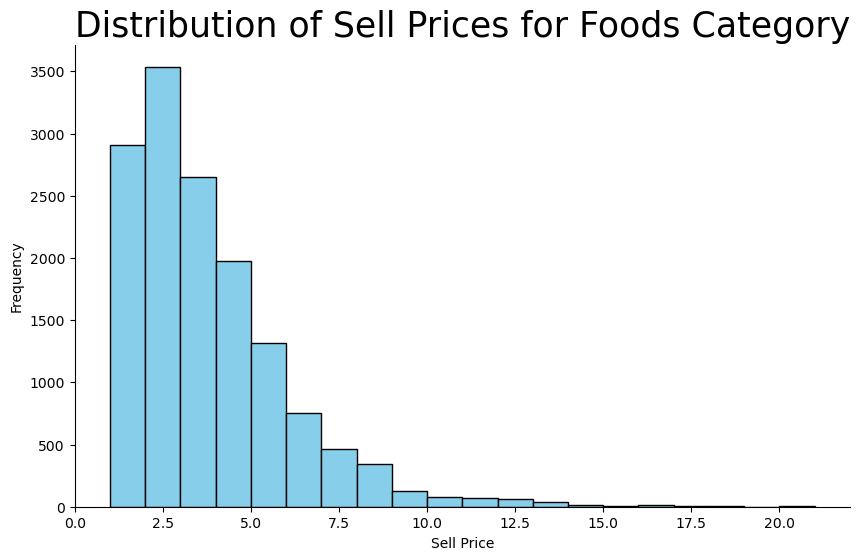

In [13]:
price_var_food = price_var.reset_index()
price_var_food = price_var_food.merge(item_map, on="item_id")
import matplotlib.pyplot as plt

prices = price_var_food[price_var_food["cat_id"] == "FOODS"]["sell_price"]

plt.figure(figsize=(10,6))
plt.hist(prices, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Sell Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sell Prices for Foods Category", size=25)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/dist_price_food.png')
plt.show()


In [14]:
df_wm_sales_e["state_id"].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

In [15]:
#data/wallmart_food_top150.csv gives wallmart data for foods category for top 150 products. 
# created in data_wallmart-food.ipynb 
df=pd.read_csv('data/wallmart_food_top150.csv', parse_dates=['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291150 entries, 0 to 291149
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    291150 non-null  int64         
 1   id            291150 non-null  object        
 2   item_id       291150 non-null  object        
 3   dept_id       291150 non-null  object        
 4   cat_id        291150 non-null  object        
 5   store_id      291150 non-null  object        
 6   state_id      291150 non-null  object        
 7   d             291150 non-null  object        
 8   sales         291150 non-null  int64         
 9   date          291150 non-null  datetime64[ns]
 10  wm_yr_wk      291150 non-null  int64         
 11  weekday       291150 non-null  object        
 12  wday          291150 non-null  int64         
 13  month         291150 non-null  int64         
 14  year          291150 non-null  int64         
 15  event_name_1  237

In [16]:
df = df.copy()

df = df.drop(columns=["Unnamed: 0"])


In [17]:
df.isna().sum()

id                   0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
d                    0
sales                0
date                 0
wm_yr_wk             0
weekday              0
wday                 0
month                0
year                 0
event_name_1    267450
event_type_1    267450
event_name_2    290550
event_type_2    290550
snap_CA              0
snap_TX              0
snap_WI              0
sell_price        7742
dtype: int64

In [18]:
#we have no null sales but 7742 prices
df[df["sell_price"].isna()]["sales"].describe()

count    7742.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: sales, dtype: float64

In [19]:
df['state_id'].value_counts()

state_id
CA    130047
WI     85404
TX     75699
Name: count, dtype: int64

### null prices: the reason there are null values in prices is that there is no sale.
- so it is structural missings
- Those rows represent:
- Item-store-day combinations where the item was not available for sale.
- There is no price because there was no listing.
- So it is not zero demand — it is probably non-availability.
- So I can drop null values in price: Demand conditional on product being offered.

In [20]:
df['sell_price'].dtype

dtype('float64')

In [21]:
df = df.sort_values(["item_id", "store_id", "date"])
df_copy=df.copy()
df_copy["sell_price"] = df_copy.groupby(["item_id", "store_id"])["sell_price"].ffill()

In [22]:
df_copy.isna().sum()

id                   0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
d                    0
sales                0
date                 0
wm_yr_wk             0
weekday              0
wday                 0
month                0
year                 0
event_name_1    267450
event_type_1    267450
event_name_2    290550
event_type_2    290550
snap_CA              0
snap_TX              0
snap_WI              0
sell_price        7742
dtype: int64

- Forward fill does not work. Why? There is no price value to forward?

In [23]:
all_nan_groups = (
    df.groupby(["item_id","store_id"])["sell_price"]
      .apply(lambda s: s.isna().all())
)

print("Groups with all NaN sell_price:", int(all_nan_groups.sum()))

Groups with all NaN sell_price: 0


- there is no such group of product with all rows are null.

In [24]:
# earliest date in each item-store group
first_date = df.groupby(["item_id","store_id"])["date"].transform("min")

# how many remaining NaNs are exactly on the first date of their group?
start_nans = df["sell_price"].isna() & (df["date"] == first_date)

print("Remaining NaNs:", df["sell_price"].isna().sum())
print("NaNs at start of group:", start_nans.sum())
print("Share at start:", start_nans.sum() / df["sell_price"].isna().sum())

Remaining NaNs: 7742
NaNs at start of group: 24
Share at start: 0.003099974166881943


- some products are introduced later on than the data started, so zero sales in those dates and 
- prices have null values. if we fill them with prices it will look like at that price level demand is zero, and model will be mislead.
- Due to this we will drop rows with missing values

In [25]:
df[df["sell_price"].isna()]["sales"].value_counts().head(10)

sales
0    7742
Name: count, dtype: int64

In [26]:
df = df.dropna(subset=["sell_price"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283408 entries, 0 to 291149
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            283408 non-null  object        
 1   item_id       283408 non-null  object        
 2   dept_id       283408 non-null  object        
 3   cat_id        283408 non-null  object        
 4   store_id      283408 non-null  object        
 5   state_id      283408 non-null  object        
 6   d             283408 non-null  object        
 7   sales         283408 non-null  int64         
 8   date          283408 non-null  datetime64[ns]
 9   wm_yr_wk      283408 non-null  int64         
 10  weekday       283408 non-null  object        
 11  wday          283408 non-null  int64         
 12  month         283408 non-null  int64         
 13  year          283408 non-null  int64         
 14  event_name_1  23076 non-null   object        
 15  event_type_1  23076 no

## Train-Test Split

In [27]:
# Last ~20% of weeks as test (time-based)
unique_weeks = np.sort(df["wm_yr_wk"].unique())
cut = int(len(unique_weeks) * 0.8)
train_weeks = set(unique_weeks[:cut])
test_weeks  = set(unique_weeks[cut:])

train = df[df["wm_yr_wk"].isin(train_weeks)].copy()
test  = df[df["wm_yr_wk"].isin(test_weeks)].copy()

print(f'min week of train: {train["wm_yr_wk"].min()} , max week of train: {train["wm_yr_wk"].max()}')
print(f'min week of test: {test["wm_yr_wk"].min()} , max week of test: {test["wm_yr_wk"].max()}')

min week of train: 11101 , max week of train: 11513
min week of test: 11514 , max week of test: 11617


In [90]:
train.tail()


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,snap_TX,snap_WI,sell_price,dayofweek,quarter,item_store,price_bin,event_name_1_clean,event_name_2_clean,event
290758,FOODS_3_811_WI_2_evaluation,FOODS_3_811,FOODS_3,FOODS,WI_2,WI,d_1550,9,2015-04-27,11513,...,0,0,1.88,0,2,FOODS_3_811_WI_2,"(1.58, 1.88]",No Event,No Event,0
290759,FOODS_3_811_WI_2_evaluation,FOODS_3_811,FOODS_3,FOODS,WI_2,WI,d_1551,4,2015-04-28,11513,...,0,0,1.88,1,2,FOODS_3_811_WI_2,"(1.58, 1.88]",No Event,No Event,0
290760,FOODS_3_811_WI_2_evaluation,FOODS_3_811,FOODS_3,FOODS,WI_2,WI,d_1552,7,2015-04-29,11513,...,0,0,1.88,2,2,FOODS_3_811_WI_2,"(1.58, 1.88]",No Event,No Event,0
290761,FOODS_3_811_WI_2_evaluation,FOODS_3_811,FOODS_3,FOODS,WI_2,WI,d_1553,5,2015-04-30,11513,...,0,0,1.88,3,2,FOODS_3_811_WI_2,"(1.58, 1.88]",No Event,No Event,0
290762,FOODS_3_811_WI_2_evaluation,FOODS_3_811,FOODS_3,FOODS,WI_2,WI,d_1554,10,2015-05-01,11513,...,1,0,1.88,4,2,FOODS_3_811_WI_2,"(1.58, 1.88]",No Event,No Event,0


In [97]:
print(f"train data: {train['date'].min()} - {train['date'].max()}")
print(f"test data: {test['date'].min()} - {test['date'].max()}")

train data: 2011-01-29 00:00:00 - 2015-05-01 00:00:00
test data: 2015-05-02 00:00:00 - 2016-05-22 00:00:00


In [29]:
print("Shape of train:", train.shape)
print("Shape of train:", train.shape)

Shape of train: (225358, 22)
Shape of train: (225358, 22)


In [30]:
#product which appears in all stores to check price variation in time and cross store
stores_per_item = train.groupby("item_id")["store_id"].nunique().sort_values(ascending=False)
print("stores_per_item:", stores_per_item.head(10)) #FOODS_3_090 appears in all 10 stores

item_best = stores_per_item.index[0]
tmp = train[(train["item_id"] == item_best) & train["sell_price"].notna()].copy()

print("Chosen item:", item_best)
print("Stores for this item:", tmp["store_id"].nunique())
print(tmp["store_id"].unique())

stores_per_item: item_id
FOODS_3_090    10
FOODS_3_586     9
FOODS_3_714     8
FOODS_3_252     7
FOODS_3_694     7
FOODS_3_555     7
FOODS_3_587     7
FOODS_3_202     6
FOODS_3_723     6
FOODS_2_360     4
Name: store_id, dtype: int64
Chosen item: FOODS_3_090
Stores for this item: 10
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']


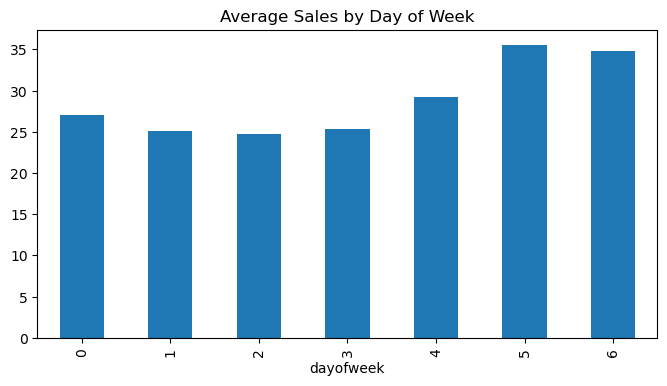

In [31]:


train['dayofweek'] = train['date'].dt.dayofweek

dow_avg = train.groupby("dayofweek")["sales"].mean()

plt.figure(figsize=(8,4))
dow_avg.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.savefig("visuals/AvgSalesbyDayofWeek.png")
plt.show()



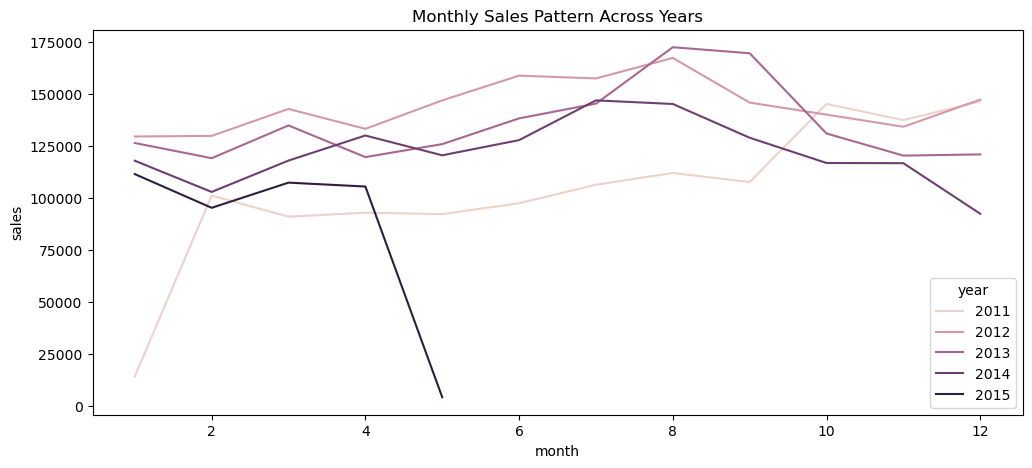

In [32]:
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year

monthly_sales = train.groupby(['year','month'])['sales'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='month', y='sales', hue='year', legend=True)
plt.title("Monthly Sales Pattern Across Years")
plt.savefig("visuals/Monthly _Sales _Pattern_Across_Years.png")
plt.show()



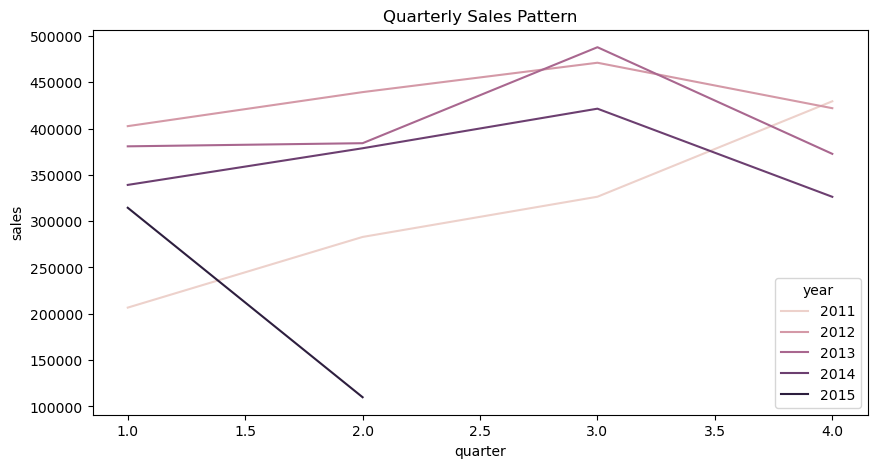

In [33]:


train['quarter'] = train['date'].dt.quarter

quarterly_sales = train.groupby(['year','quarter'])['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=quarterly_sales, x='quarter', y='sales', hue='year')
plt.title("Quarterly Sales Pattern")
plt.show()



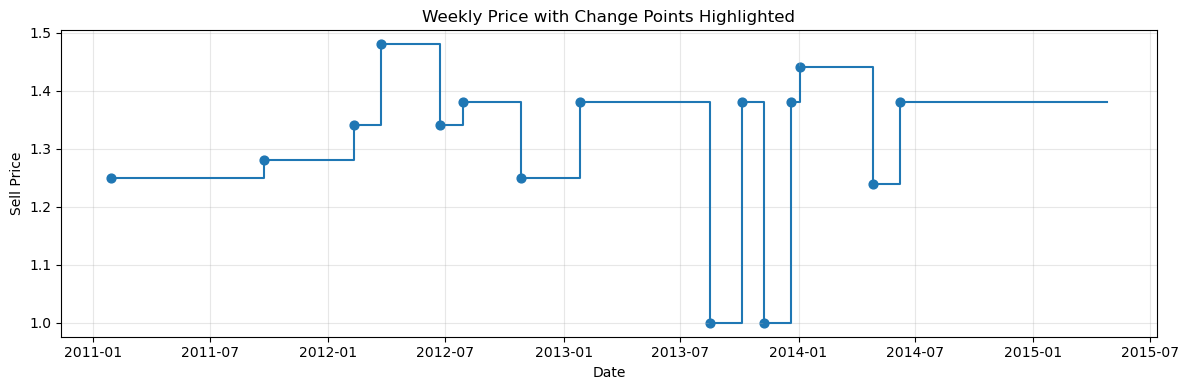

In [34]:
#Weekly Price Change Points for one product from one store

w12_item3090 = train.loc[
    (train["item_id"] == item_best) & (train["store_id"] == "WI_2")
].copy()
weekly_price = (
    w12_item3090 
    .sort_values("date")
    .groupby("wm_yr_wk", as_index=False)
    .agg(date=("date", "min"),
         sell_price=("sell_price", "first"))
)
weekly_price["price_changed"] = weekly_price["sell_price"].diff().ne(0)

plt.figure(figsize=(12,4))
plt.plot(
    weekly_price["date"],
    weekly_price["sell_price"],
    drawstyle="steps-post"
)

plt.scatter(
    weekly_price.loc[weekly_price["price_changed"], "date"],
    weekly_price.loc[weekly_price["price_changed"], "sell_price"],
    s=40
)

plt.title("Weekly Price with Change Points Highlighted")
plt.xlabel("Date")
plt.ylabel("Sell Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
#This shows us that store based modelling would not be statistically meaningful, as limited variation for precise single-store elasticity
num_changes = weekly_price["price_changed"].sum()
total_weeks = len(weekly_price)

print("Total weeks:", total_weeks)
print("Number of price changes:", int(num_changes))
print("Change frequency:", num_changes / total_weeks)

Total weeks: 222
Number of price changes: 15
Change frequency: 0.06756756756756757


In [36]:
print(f'Number of items: {train["item_id"].nunique()}')
print(f'Number of departments: {train["dept_id"].nunique()}')
print(f'Number of categories: {train["cat_id"].nunique()}')
print(f'Number of stores: {train["store_id"].nunique()}')
print(f'Number of states: {train["state_id"].nunique()}')

Number of items: 56
Number of departments: 3
Number of categories: 1
Number of stores: 10
Number of states: 3


In [37]:
train.shape

(225358, 24)

items sold everday
check null values for single item
how often prices change
clean data
milestone for each week


For demand + pricing model:
analysis/modelling level:

item_id × store_id × date



## EDA
- Total sales by store
- Total sales in time
- What are we selling?
- How does demand behave?
- How often do prices change?
- Is there price sensitivity?
- Are there seasonal effects?
- Is there cross-store variation?

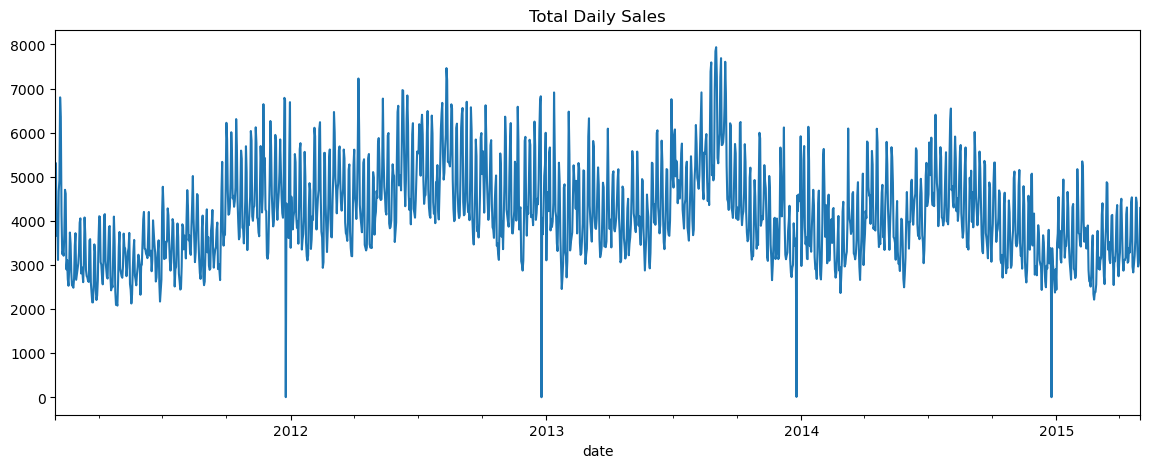

In [38]:

daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(14,5))
daily_sales.plot()
plt.title("Total Daily Sales")
plt.savefig("visuals/Total_Daily_Sales.png")
plt.show()


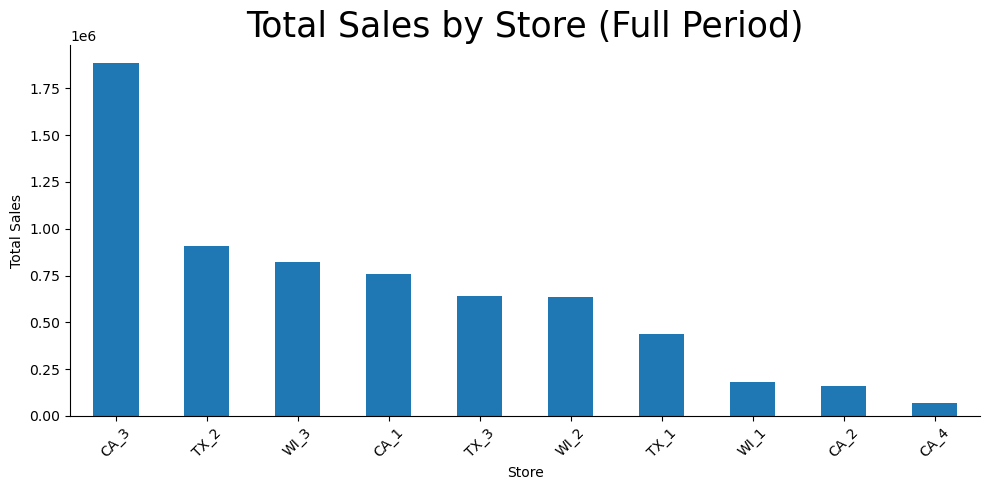

In [39]:
# Total sales per store
total_sales_store = (
    train.groupby("store_id")["sales"]
      .sum()
      .sort_values(ascending=False)
)

#print(total_sales_store)

plt.figure(figsize=(10,5))
total_sales_store.plot(kind="bar")
plt.title("Total Sales by Store (Full Period)", fontsize=25)
plt.ylabel("Total Sales")
plt.xlabel("Store")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.savefig('totalsales.png')
plt.show()

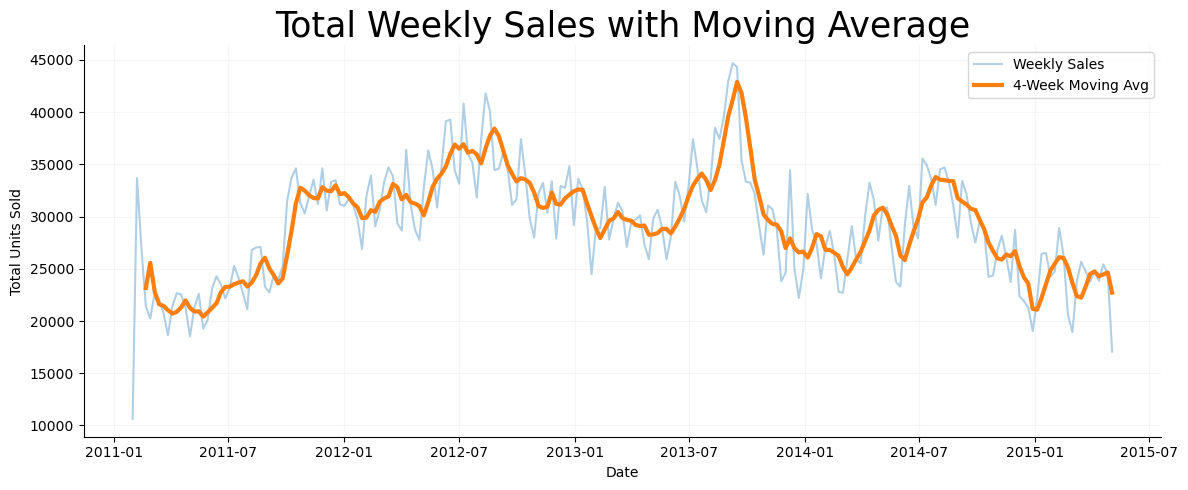

In [40]:
# Weekly total sales
weekly_total_sales = (
    train.groupby(pd.Grouper(key="date", freq="W"))["sales"]
      .sum()
      .reset_index()
)

# 4-week moving average (≈1 month smoothing)
weekly_total_sales["sales_ma4"] = (
    weekly_total_sales["sales"]
    .rolling(window=4)
    .mean()
)

plt.figure(figsize=(12,5))

# Raw weekly sales
plt.plot(
    weekly_total_sales["date"],
    weekly_total_sales["sales"],
    alpha=0.35,
    label="Weekly Sales"
)

# Moving average
plt.plot(
    weekly_total_sales["date"],
    weekly_total_sales["sales_ma4"],
    linewidth=3,
    label="4-Week Moving Avg"
)

plt.title("Total Weekly Sales with Moving Average", size=25)
plt.ylabel("Total Units Sold")
plt.xlabel("Date")
plt.legend()

plt.grid(alpha=0.1)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("visuals/foodsales_weekly_moving_avg.png")
plt.show()

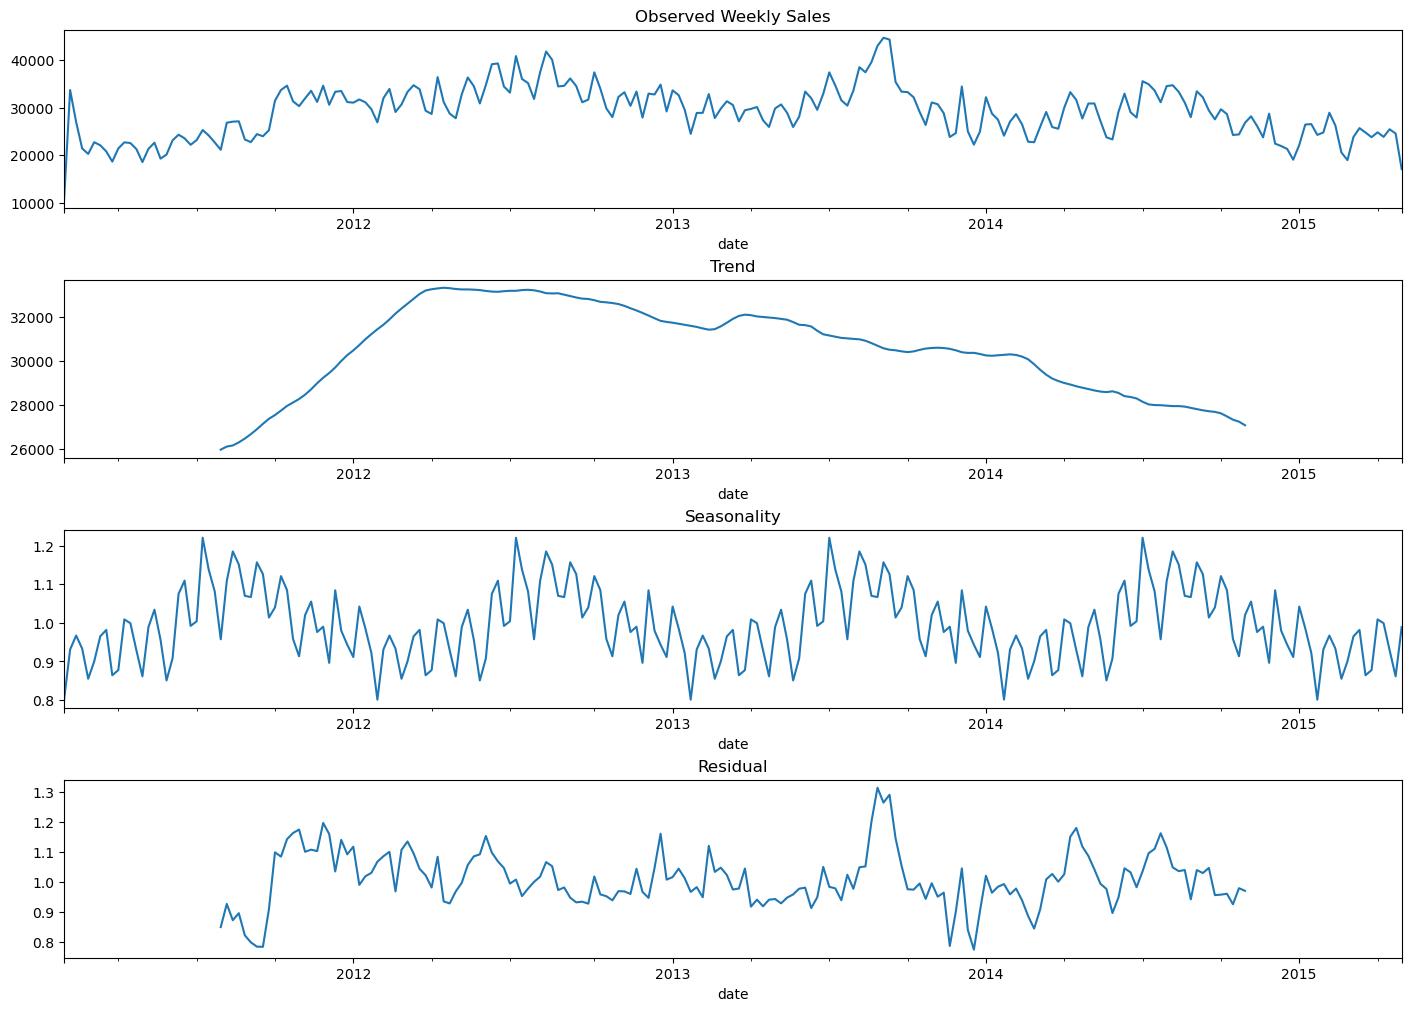

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

weekly_series = weekly_total_sales.set_index("date")["sales"]

decomposition = seasonal_decompose(
    weekly_series,
    model="multiplicative",
    period=52
)
fig, ax = plt.subplots(4, 1, figsize=(14,10), constrained_layout=True)

decomposition.observed.plot(ax=ax[0])
ax[0].set_title("Observed Weekly Sales")

decomposition.trend.plot(ax=ax[1])
ax[1].set_title("Trend")

decomposition.seasonal.plot(ax=ax[2])
ax[2].set_title("Seasonality")

decomposition.resid.plot(ax=ax[3])
ax[3].set_title("Residual")

plt.savefig("visuals/weekly_sales_decomposition.png")
plt.show()

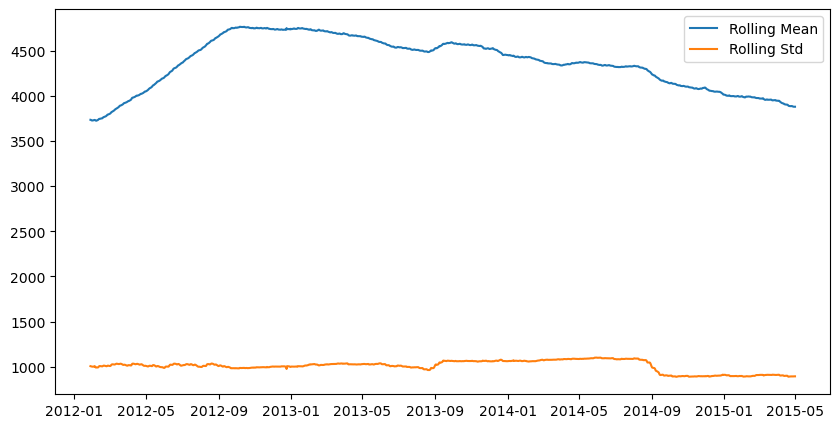

In [42]:
daily_sales = train.groupby("date")["sales"].sum()

rolling_std = daily_sales.rolling(365).std()
rolling_mean = daily_sales.rolling(365).mean()

plt.figure(figsize=(10,5))
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.show()

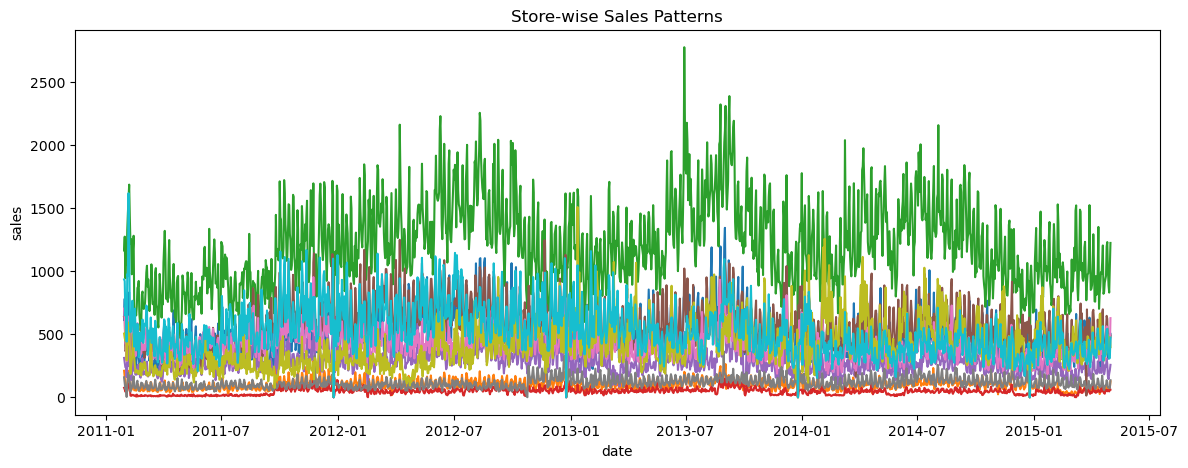

In [43]:


store_sales = train.groupby(["date","store_id"])["sales"].sum().reset_index()

plt.figure(figsize=(14,5))
sns.lineplot(data=store_sales, x="date", y="sales", hue="store_id", legend=False)
plt.title("Store-wise Sales Patterns")
plt.show()



- 1: Strong week-to-week volatility, Demand roughly between 20k–40k units, 2013 peak, decline after 2014==>Retail demand is highly noisy, which is why smoothing (moving averages) and modeling are necessary.
- 2: Growth from 2011 → mid-2012, Plateau around 2012–2013, Gradual decline 2013 → 2015, Slight stabilization afterward (not stationary)
- seasonality: repeating yearly cycle.holidays, weather, school cycles, SNAP payments
- Residual: Residuals represent: price shocks, promotions, inventory shortages, random demand shocks
- ==> typical retail data
- Time series decomposition reveals a clear yearly seasonal pattern and a declining long-term demand - - trend after 2013. Weekly demand exhibits significant volatility, highlighting the need for models - -that control for seasonality and capture dynamic demand behavior.

<Figure size 1000x400 with 0 Axes>

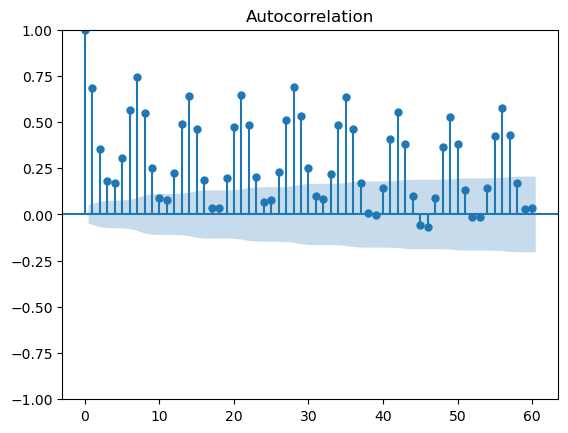

In [44]:


from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(daily_sales, lags=60)
plt.show()



<Figure size 1000x400 with 0 Axes>

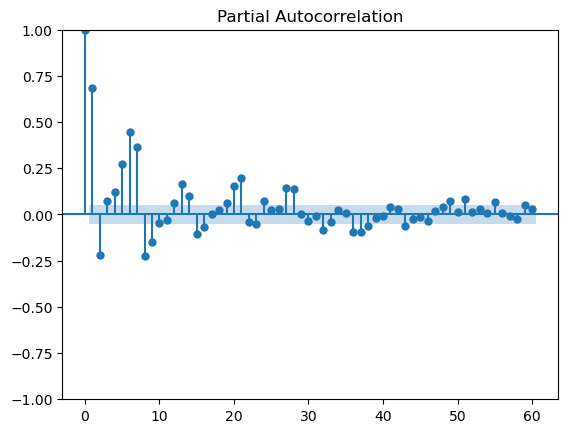

In [45]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,4))
plot_pacf(daily_sales, lags=60)
plt.show()

In [46]:
#Stationary check

from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])



ADF Statistic: -2.9422438168241962
p-value: 0.04065154642552735




    Although the ADF test returns a p-value below 0.05, the presence of clear trend and multiplicative seasonality suggests the series is not strictly stationary in a practical forecasting sense.

ADF tests for unit root stochastic trends, but deterministic trend and seasonality still require transformation (e.g., differencing or log-transform).


In [47]:
df_item1=train[train['item_id']=='FOODS_3_090']

In [48]:
df_item1["price_change"] = df_item1["sell_price"].diff().abs()

num_changes = (df_item1["price_change"] > 0).sum()
total_days = len(df_item1)

print("Price changes:", num_changes)
print("Total days:", total_days)
print("Change frequency:", num_changes / total_days)

Price changes: 156
Total days: 15540
Change frequency: 0.010038610038610039


In [49]:
train.groupby("item_id")["sell_price"].nunique().describe()

count    56.000000
mean      3.892857
std       3.084734
min       1.000000
25%       2.000000
50%       3.000000
75%       5.000000
max      17.000000
Name: sell_price, dtype: float64

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_series = (
    train.sort_values("date")
      .set_index("date")["sales"]
)

decomposition = seasonal_decompose(
    daily_series,
    model="additive",
    period=7
)

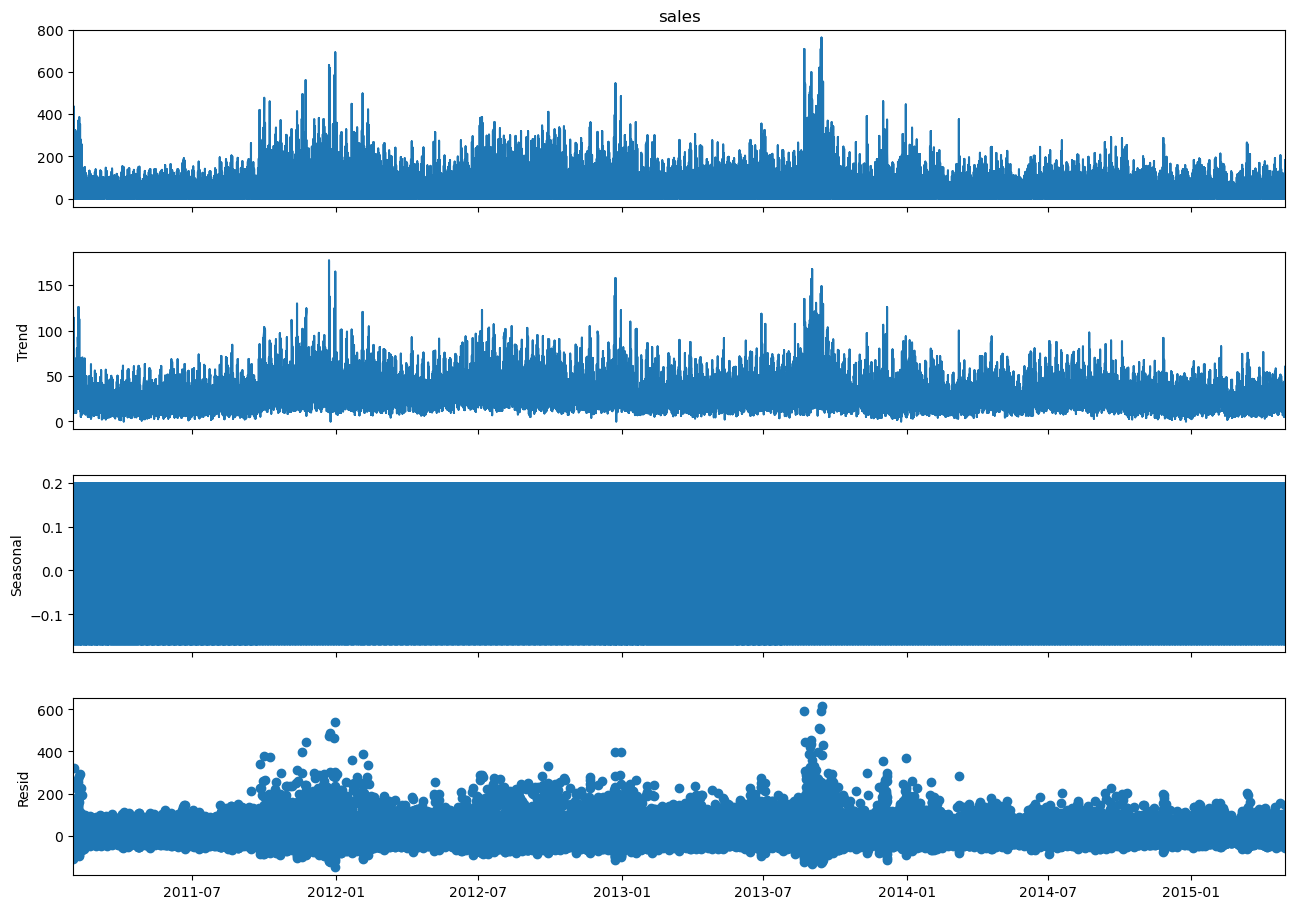

In [51]:
fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.savefig("visuals/daily_sales_decomposition.png")
plt.show()

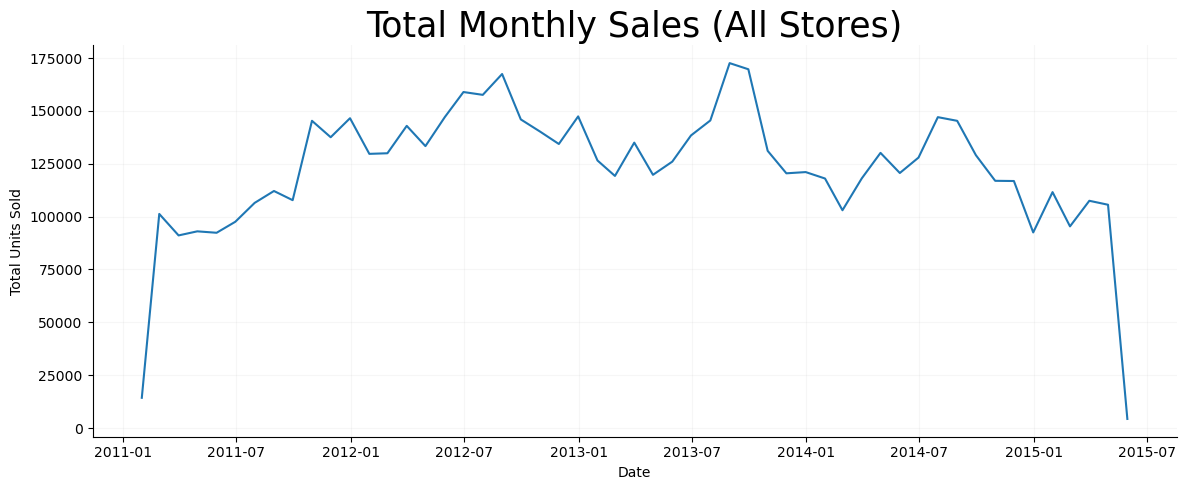

In [52]:
monthly_total_sales = (
    train.groupby(pd.Grouper(key="date", freq="ME"))["sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(monthly_total_sales["date"],
         monthly_total_sales["sales"])
plt.title("Total Monthly Sales (All Stores)", size=25)
plt.ylabel("Total Units Sold")
plt.xlabel("Date")
plt.grid(alpha=0.1)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/foodsales_intime_monthly.png')
plt.tight_layout()
plt.show()

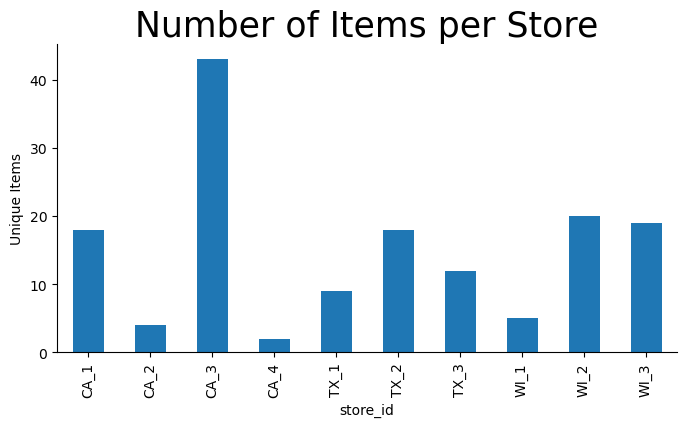

In [53]:
#What are we selling? 
train.groupby("store_id")["item_id"].nunique().plot(kind="bar", figsize=(8,4))
plt.title("Number of Items per Store", size=25)
plt.ylabel("Unique Items")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/nu_ites_per_store.png')
plt.show()


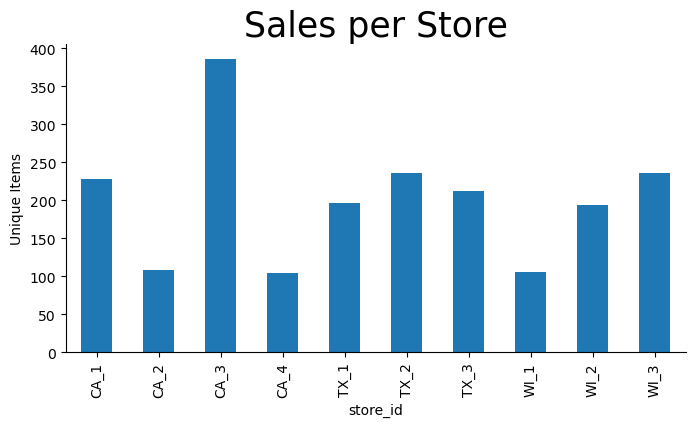

In [54]:
#What are we selling? 
train.groupby("store_id")["sales"].nunique().plot(kind="bar", figsize=(8,4))
plt.title("Sales per Store", size=25)
plt.ylabel("Unique Items")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/sales_per_store.png')
plt.show()

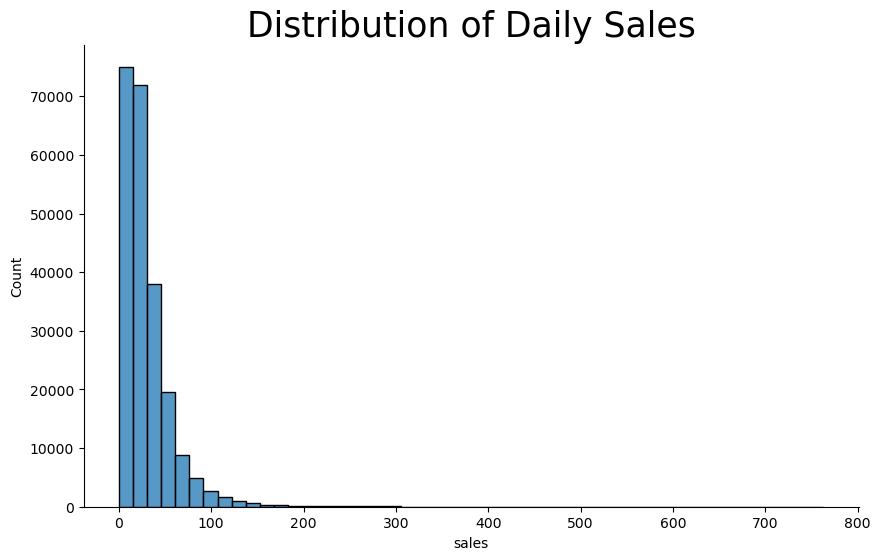

In [55]:
#Distribution of sales by prices

plt.figure(figsize=(10,6))
sns.histplot(train["sales"], bins=50)
plt.title("Distribution of Daily Sales", size=25)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/dist_daily_sales.png')
plt.show()

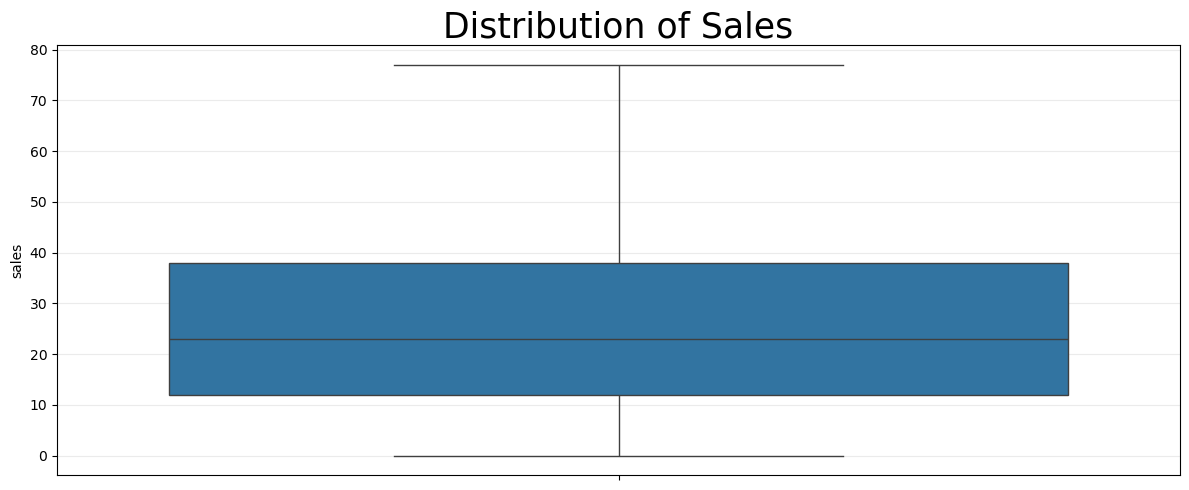

In [56]:
plt.figure(figsize=(12,5))
sales=train['sales']
sns.boxplot(data=sales, showfliers=False)
plt.title("Distribution of Sales", size=25)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig('box_plotDistofSales.png')
plt.show()

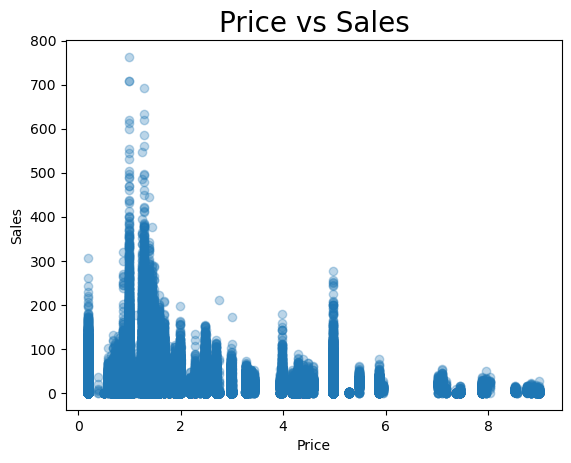

In [57]:

plt.scatter(train["sell_price"], train["sales"], alpha=0.3)

plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Price vs Sales", size=20)
plt.savefig("visuals/pricevssales.png")
plt.show()

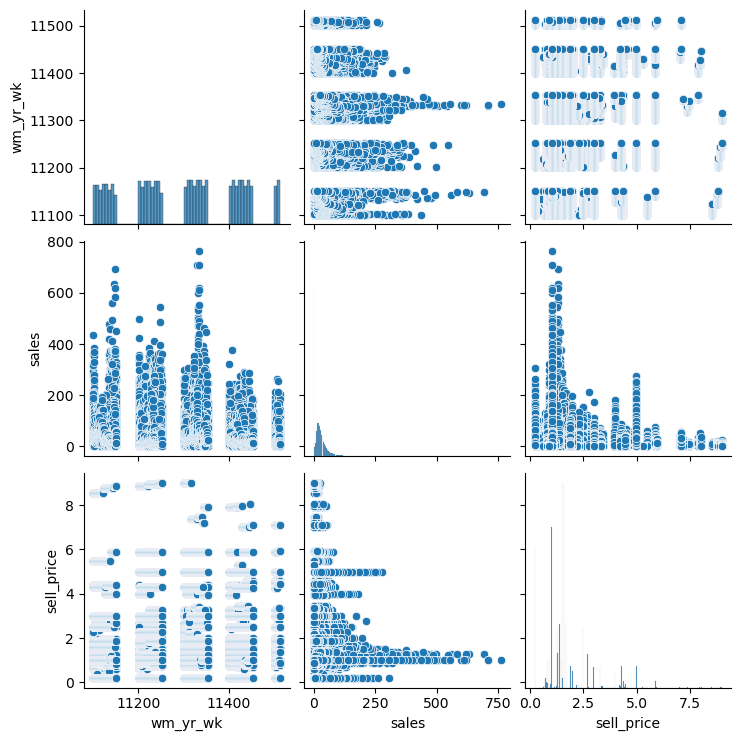

In [58]:
sns.pairplot(train[["wm_yr_wk","sales", "sell_price"]]);

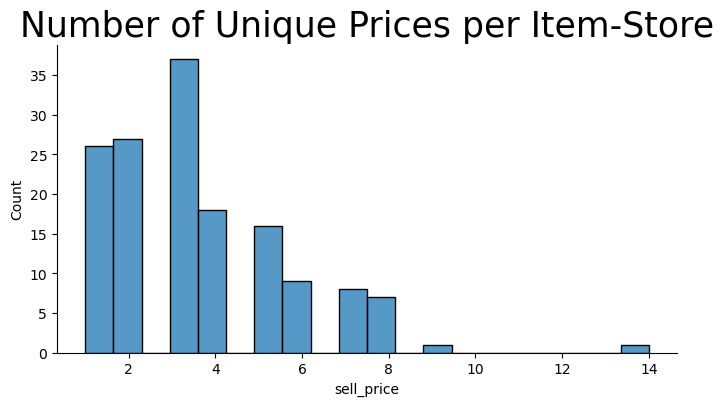

In [59]:
# Price changes
price_var = (
    train.groupby(["item_id","store_id"])["sell_price"]
      .nunique()
)

plt.figure(figsize=(8,4))
sns.histplot(price_var, bins=20)
plt.title("Number of Unique Prices per Item-Store", size=25)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/nu_unique_prices_per_item_store.png')
plt.show()

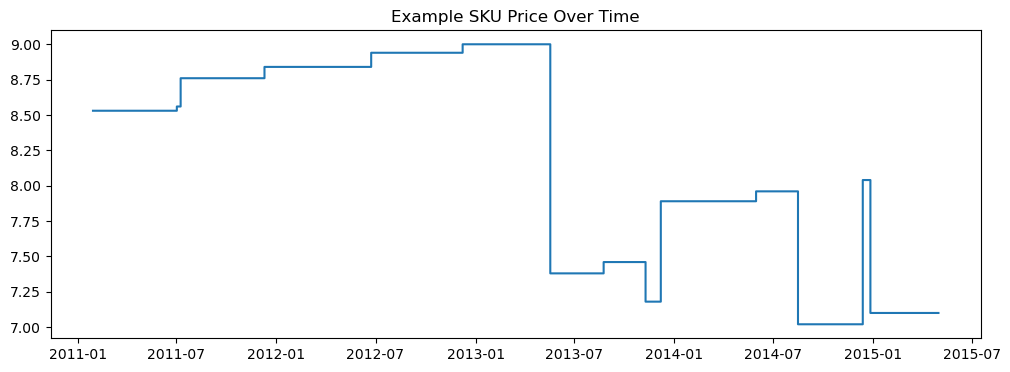

In [60]:
train["item_store"] = train["item_id"] + "_" + train["store_id"]
sample = train[train["item_store"] == train["item_store"].unique()[0]].copy()

plt.figure(figsize=(12,4))
plt.plot(sample["date"], sample["sell_price"], drawstyle="steps-post")
plt.title("Example SKU Price Over Time")
plt.show()

In [61]:


item_best = stores_per_item.index[0]
tmp = df[(df["item_id"] == item_best) & df["sell_price"].notna()].copy()

print("Chosen item:", item_best)
print("Stores for this item:", tmp["store_id"].nunique())
print(tmp["store_id"].unique())



Chosen item: FOODS_3_090
Stores for this item: 10
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']


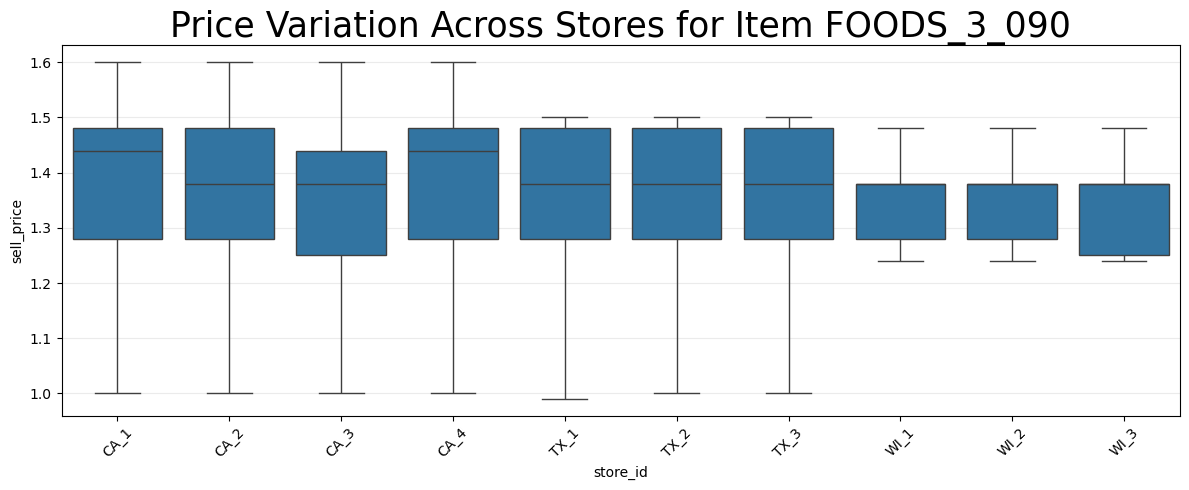

In [62]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.boxplot(data=tmp, x="store_id", y="sell_price", showfliers=False)
plt.title(f"Price Variation Across Stores for Item {item_best}", size=25)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig('visuals/Price_Var_AcStores_forf3090.png')
plt.show()



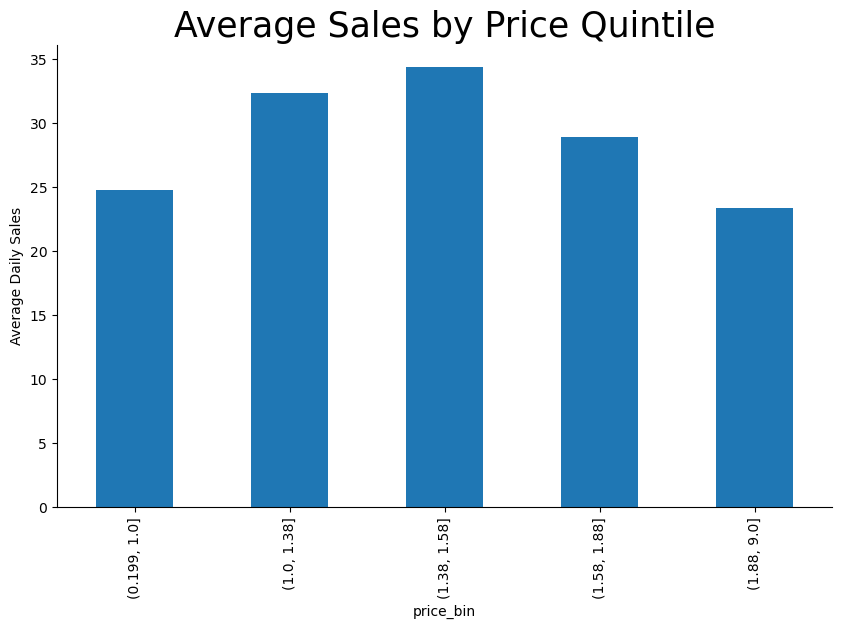

In [63]:
train["price_bin"] = pd.qcut(train["sell_price"], q=5, duplicates="drop")

price_demand = (
    train.groupby("price_bin")["sales"]
      .mean()
)

price_demand.plot(kind="bar", figsize=(10,6))
plt.title("Average Sales by Price Quintile", size=25)
plt.ylabel("Average Daily Sales")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig('visuals/avg_sales_price_quintile.png')
plt.show()

In [64]:
#product which appears in all stores to check price variation in time and cross store
stores_per_item = train.groupby("item_id")["store_id"].nunique().sort_values(ascending=False)
stores_per_item.head(10)

item_id
FOODS_3_090    10
FOODS_3_586     9
FOODS_3_714     8
FOODS_3_252     7
FOODS_3_694     7
FOODS_3_555     7
FOODS_3_587     7
FOODS_3_202     6
FOODS_3_723     6
FOODS_2_360     4
Name: store_id, dtype: int64

In [65]:
item_best = stores_per_item.index[0]
tmp = train[(train["item_id"] == item_best) & df["sell_price"].notna()].copy()

print("Chosen item:", item_best)
print("Stores for this item:", tmp["store_id"].nunique())
print(tmp["store_id"].unique())

Chosen item: FOODS_3_090
Stores for this item: 10
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']


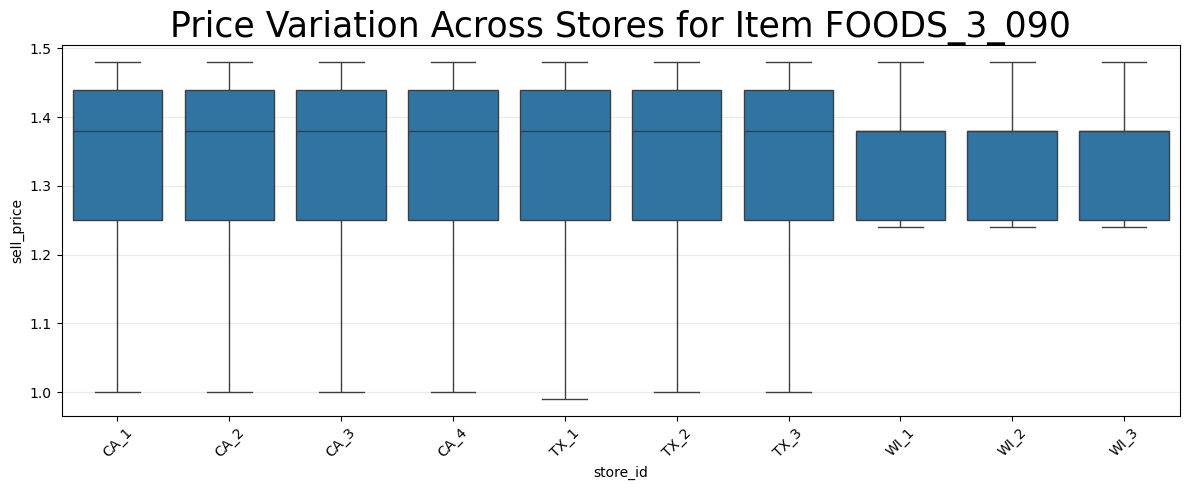

In [66]:
plt.figure(figsize=(12,5))
sns.boxplot(data=tmp, x="store_id", y="sell_price", showfliers=False)
plt.title(f"Price Variation Across Stores for Item {item_best}", size=25)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig('visuals/Price_Var_AcStores_forf3090.png')
plt.show()

- CA stores have slightly higher median prices (1.38–1.45), TX stores are similar but slightly lower
WI stores are clearly lowest (~1.28–1.35)
- ==> so both within (whiskers from ~1.0 to ~1.6) store (in time) and cross store price variation (heterogenity) exists.
* Within-store time variation
* Prices move over time within each store.
* Cross-store level differences:Same item has systematically different price levels across states.
- ==> Likely different promotion timing. 


In [67]:
monthly_price = (
    train.groupby(["item_id", "store_id", pd.Grouper(key="date", freq="M")])["sell_price"]
      .mean()
      .reset_index()
)

In [68]:
# Compute total sales per store
store_sales = train.groupby("store_id")["sales"].sum().sort_values(ascending=False)

print(store_sales)

# Select the biggest store
largest_store = store_sales.index[0]
print("Largest store:", largest_store)

store_id
CA_3    1884619
TX_2     908792
WI_3     823550
CA_1     755655
TX_3     639515
WI_2     634698
TX_1     440277
WI_1     179682
CA_2     157550
CA_4      71757
Name: sales, dtype: int64
Largest store: CA_3


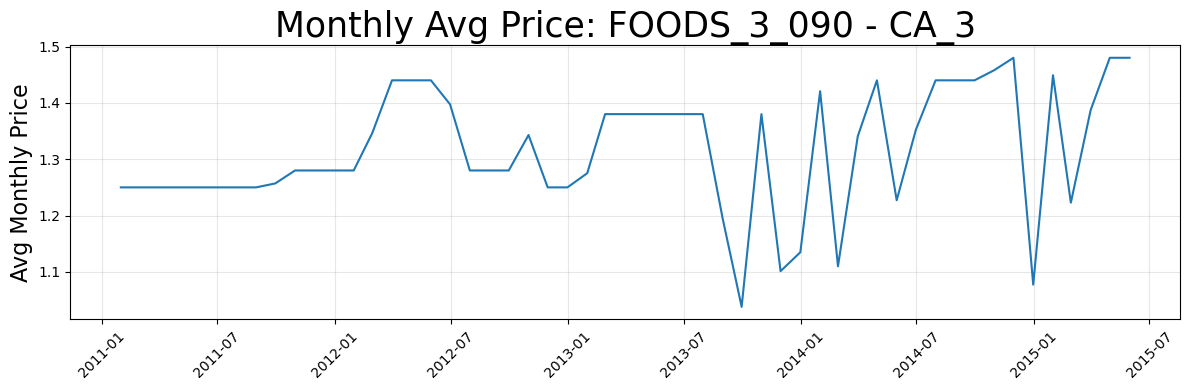

In [69]:
item = item_best
store = largest_store

tmp = monthly_price[
    (monthly_price["item_id"] == item_best) &
    (monthly_price["store_id"] == store)
]

plt.figure(figsize=(12,4))
plt.plot(tmp["date"], tmp["sell_price"])
plt.title(f"Monthly Avg Price: {item} - {store}", size=25)
plt.ylabel("Avg Monthly Price", size=16)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('visuals/Avgprice_OneProduct.png')
plt.show()

- sharp downward spikes (~1.05) are classic temporary discounts.
- Price is not random==> predictable
- not constant==> calculatable price elasticities
- Price changes are economically structured: There are both temporary shocks and long-term shifts
* this gives us:
* Short-run elasticity identification
* Long-run price level shifts
* Promotion response analysis: important for simulations!!! So Revenue simulation scenarios

In [70]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225358 entries, 0 to 290762
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            225358 non-null  object        
 1   item_id       225358 non-null  object        
 2   dept_id       225358 non-null  object        
 3   cat_id        225358 non-null  object        
 4   store_id      225358 non-null  object        
 5   state_id      225358 non-null  object        
 6   d             225358 non-null  object        
 7   sales         225358 non-null  int64         
 8   date          225358 non-null  datetime64[ns]
 9   wm_yr_wk      225358 non-null  int64         
 10  weekday       225358 non-null  object        
 11  wday          225358 non-null  int64         
 12  month         225358 non-null  int32         
 13  year          225358 non-null  int32         
 14  event_name_1  18276 non-null   object        
 15  event_type_1  18276 no

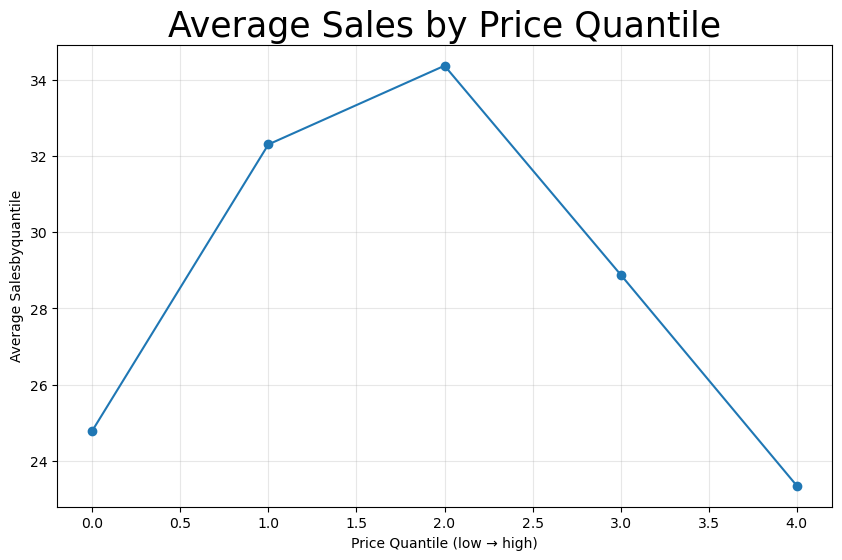

In [71]:
train["price_bin"] = pd.qcut(train["sell_price"], q=5)

price_demand = (
    train.groupby("price_bin")["sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
plt.plot(price_demand.index, price_demand["sales"], marker="o")

plt.title("Average Sales by Price Quantile", size=25)
plt.xlabel("Price Quantile (low → high)")
plt.ylabel("Average Salesbyquantile")
plt.grid(alpha=0.3)
plt.savefig('visuals/AvgSalesbyPriceQuantile.png')
plt.show()

## EDA and Base Model for one product 
- (the product chosen is available in every store)


In [72]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

SKU = "FOODS_3_090"   # <- change if needed

train_sku = train.loc[train["item_id"] == SKU].copy()
train_sku["date"] = pd.to_datetime(train_sku["date"])

# Keep only rows with observed price (availability)
train_sku = train_sku.dropna(subset=["sell_price"]).copy()

# Weekly aggregation: sales=sum, price=first (weekly constant), state_id=first
weekly_sku = (
    train_sku.sort_values(["store_id", "wm_yr_wk", "date"])
          .groupby(["store_id", "wm_yr_wk"], as_index=False)
          .agg(
              week_start=("date", "min"),
              sales=("sales", "sum"),
              sell_price=("sell_price", "first"),
              state_id=("state_id", "first"),
              snap_CA=("snap_CA", "max"),
              snap_TX=("snap_TX", "max"),
              snap_WI=("snap_WI", "max"),
          )
)

# logs for elasticity
weekly_sku["log_sales"] = np.log1p(weekly_sku["sales"])
weekly_sku["log_price"] = np.log(weekly_sku["sell_price"])

weekly_sku.head()



,store_id,wm_yr_wk,week_start,sales,sell_price,state_id,snap_CA,snap_TX,snap_WI,log_sales,log_price
0,CA_1,11101,2011-01-29,616,1.25,CA,1,1,1,6.424869,0.223144
1,CA_1,11102,2011-02-05,323,1.25,CA,1,1,1,5.780744,0.223144
2,CA_1,11103,2011-02-12,0,1.25,CA,0,1,1,0.000000,0.223144
3,CA_1,11104,2011-02-19,0,1.25,CA,0,0,0,0.000000,0.223144
4,CA_1,11105,2011-02-26,0,1.25,CA,1,1,1,0.000000,0.223144


In [73]:
weekly_sku.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2220 entries, 0 to 2219
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   store_id    2220 non-null   object        
 1   wm_yr_wk    2220 non-null   int64         
 2   week_start  2220 non-null   datetime64[ns]
 3   sales       2220 non-null   int64         
 4   sell_price  2220 non-null   float64       
 5   state_id    2220 non-null   object        
 6   snap_CA     2220 non-null   int64         
 7   snap_TX     2220 non-null   int64         
 8   snap_WI     2220 non-null   int64         
 9   log_sales   2220 non-null   float64       
 10  log_price   2220 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(5), object(2)
memory usage: 190.9+ KB


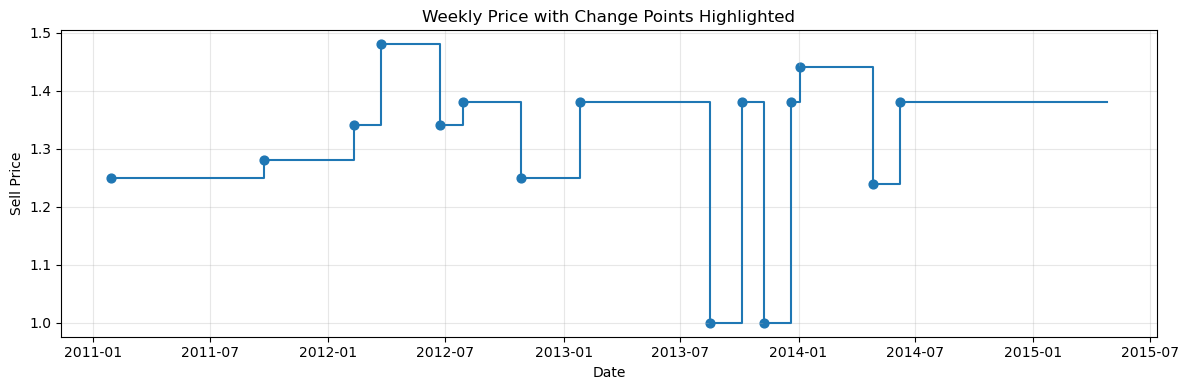

In [74]:
#Weekly Price Change Points for one product
weekly_price = (
    w12_item3090
    .sort_values("date")
    .groupby("wm_yr_wk", as_index=False)
    .agg(date=("date", "min"),
         sell_price=("sell_price", "first"))
)
weekly_price["price_changed"] = weekly_price["sell_price"].diff().ne(0)

plt.figure(figsize=(12,4))
plt.plot(
    weekly_price["date"],
    weekly_price["sell_price"],
    drawstyle="steps-post"
)

plt.scatter(
    weekly_price.loc[weekly_price["price_changed"], "date"],
    weekly_price.loc[weekly_price["price_changed"], "sell_price"],
    s=40
)

plt.title("Weekly Price with Change Points Highlighted")
plt.xlabel("Date")
plt.ylabel("Sell Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
print("event_name_1: ", train["event_name_1"].value_counts())
print("event_name_2: ", train["event_name_2"].value_counts())
print("event_type_1: ", train["event_type_1"].value_counts())
print("event_type_2: ", train["event_type_2"].value_counts())

event_name_1:  event_name_1
Pesach End             728
Purim End              725
PresidentsDay          724
LentStart              724
SuperBowl              724
ValentinesDay          724
StPatricksDay          724
LentWeek2              724
Easter                 593
MartinLutherKingDay    583
Chanukah End           582
Christmas              582
OrthodoxChristmas      582
NewYear                582
VeteransDay            581
ColumbusDay            581
Thanksgiving           581
EidAlAdha              581
Halloween              581
Eid al-Fitr            580
LaborDay               580
NBAFinalsStart         579
MemorialDay            579
IndependenceDay        579
Ramadan starts         579
NBAFinalsEnd           579
OrthodoxEaster         578
Mother's day           578
Cinco De Mayo          430
Father's day           429
Name: count, dtype: int64
event_name_2:  event_name_2
Father's day      150
OrthodoxEaster    150
Cinco De Mayo     148
Easter            135
Name: count, dtype: 

In [76]:
train.shape, (train["event_name_1"].isna() & train["event_name_2"].isna()).sum()

((225358, 26), 207082)

In [77]:
train.loc[train["event_name_2"].notna(), ["event_name_1", "event_name_2"]]

,event_name_1,event_name_2
85,OrthodoxEaster,Easter
827,OrthodoxEaster,Cinco De Mayo
1177,Easter,OrthodoxEaster
1233,NBAFinalsEnd,Father's day
2026,OrthodoxEaster,Easter
...,...,...
288445,Easter,OrthodoxEaster
288501,NBAFinalsEnd,Father's day
290036,OrthodoxEaster,Cinco De Mayo
290386,Easter,OrthodoxEaster


In [78]:
train["event_name_1_clean"] = train["event_name_1"].fillna("No Event")
train["event_name_2_clean"] = train["event_name_2"].fillna("No Event")

In [79]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225358 entries, 0 to 290762
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  225358 non-null  object        
 1   item_id             225358 non-null  object        
 2   dept_id             225358 non-null  object        
 3   cat_id              225358 non-null  object        
 4   store_id            225358 non-null  object        
 5   state_id            225358 non-null  object        
 6   d                   225358 non-null  object        
 7   sales               225358 non-null  int64         
 8   date                225358 non-null  datetime64[ns]
 9   wm_yr_wk            225358 non-null  int64         
 10  weekday             225358 non-null  object        
 11  wday                225358 non-null  int64         
 12  month               225358 non-null  int32         
 13  year                225358 non-nul

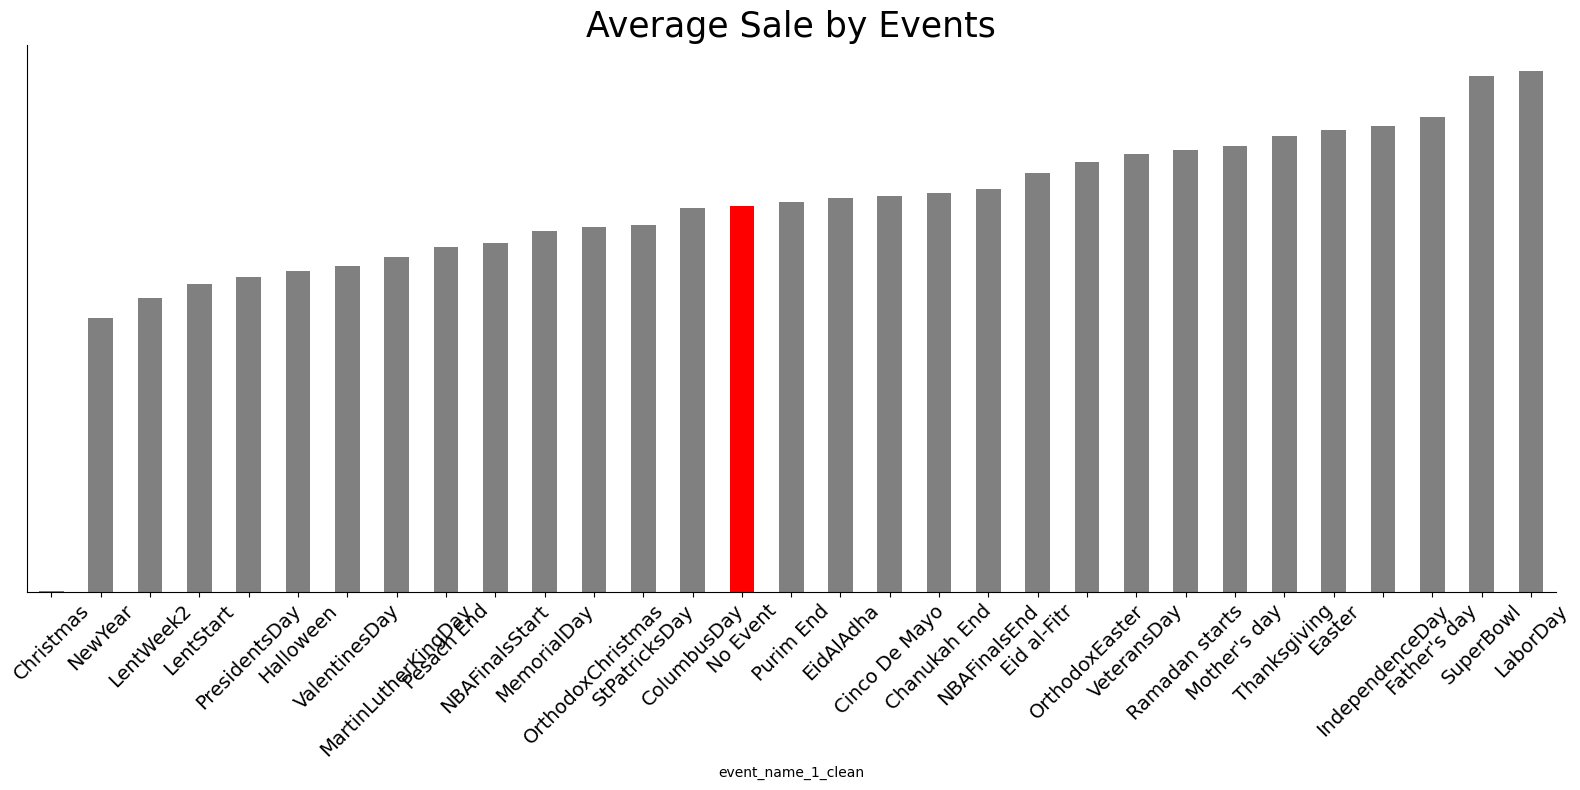

In [80]:
fig, ax = plt.subplots(figsize=(16,8))

# Compute averages
avg_sales = train.groupby('event_name_1_clean')['sales'].mean().sort_values()

# Create colors: red for "No Event", gray for others
colors = ['red' if event == 'No Event' else 'gray' for event in avg_sales.index]

# Plot
avg_sales.plot(kind='bar', color=colors, ax=ax)

# Formatting
ax.set_yticks([])
ax.set_title("Average Sale by Events", size=25)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, size=14)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("visuals/avgsales_events.png")
plt.show()


In [81]:
avg_sales

event_name_1_clean
Christmas               0.058419
NewYear                20.484536
LentWeek2              22.002762
LentStart              23.011050
PresidentsDay          23.564917
Halloween              23.993115
ValentinesDay          24.429558
MartinLutherKingDay    25.058319
Pesach End             25.815934
NBAFinalsStart         26.088083
MemorialDay            26.987910
OrthodoxChristmas      27.336770
StPatricksDay          27.443370
ColumbusDay            28.776248
No Event               28.875576
Purim End              29.215172
EidAlAdha              29.456110
Cinco De Mayo          29.637209
Chanukah End           29.888316
NBAFinalsEnd           30.145078
Eid al-Fitr            31.384483
OrthodoxEaster         32.169550
VeteransDay            32.822719
Ramadan starts         33.115717
Mother's day           33.404844
Thanksgiving           34.125645
Easter                 34.620573
IndependenceDay        34.886010
Father's day           35.543124
SuperBowl              3

In [82]:
train['sales'].mean()

28.825668491910648

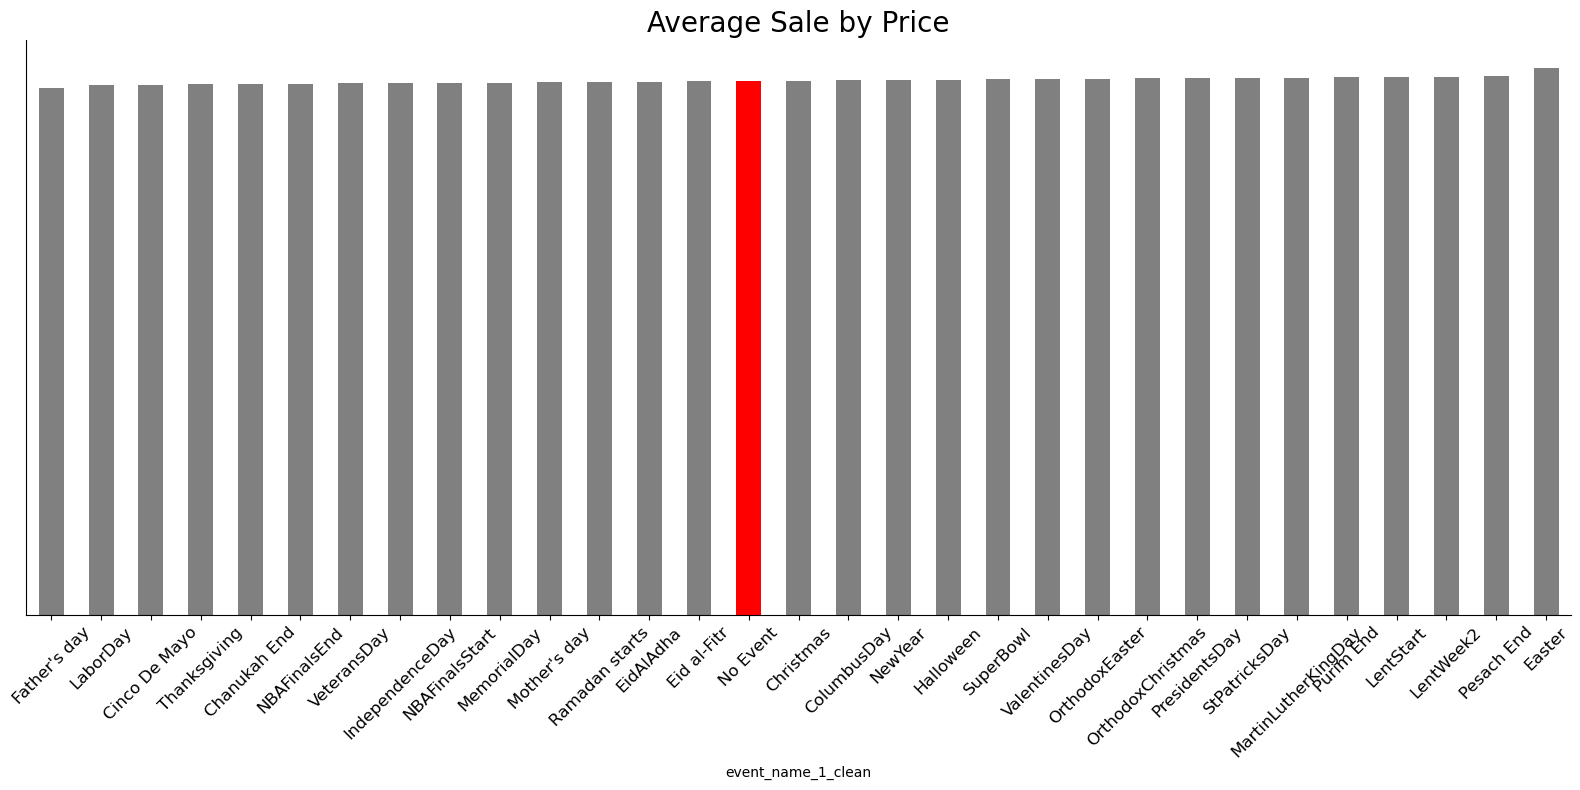

In [83]:
fig, ax = plt.subplots(figsize=(16,8))

# Compute averages
avg_prices = train.groupby('event_name_1_clean')['sell_price'].mean().sort_values()

# Create colors: red for "No Event", gray for others
colors = ['red' if event == 'No Event' else 'gray' for event in avg_sales.index]

# Plot
avg_prices.plot(kind='bar', color=colors, ax=ax)

# Formatting
ax.set_yticks([])
ax.set_title("Average Sale by Price", size=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, size=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

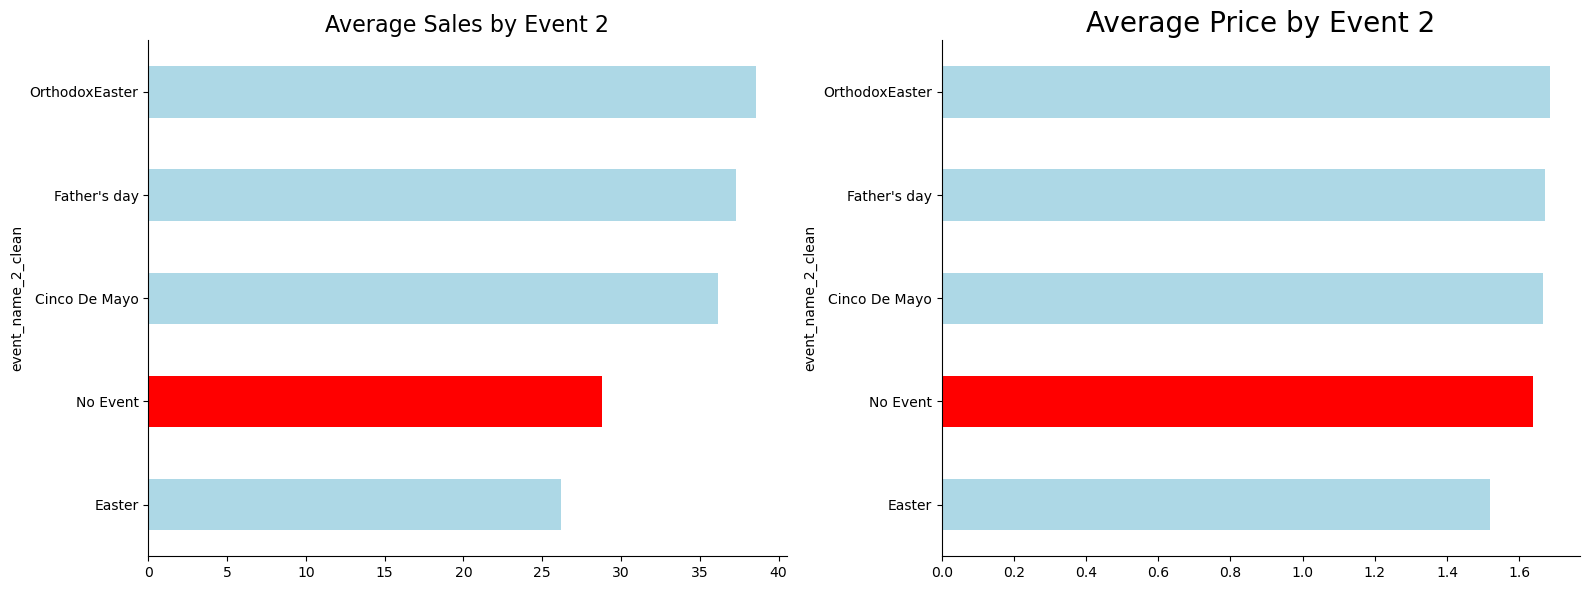

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Compute grouped averages
avg_sales = train.groupby('event_name_2_clean')['sales'].mean().sort_values()
avg_price = train.groupby('event_name_2_clean')['sell_price'].mean().sort_values()

# Create colors: red for No Event
colors = ['red' if event == 'No Event' else 'lightblue' for event in avg_sales.index]

# Plot sales
avg_sales.plot(kind='barh', color=colors, ax=ax[0])

ax[0].set_title("Average Sales by Event 2", size=16)
ax[0].grid(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# Plot prices
avg_price.plot(kind='barh', color=colors, ax=ax[1])

ax[1].set_title("Average Price by Event 2", size=20)
ax[1].grid(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [85]:
train.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'dayofweek', 'quarter',
       'item_store', 'price_bin', 'event_name_1_clean', 'event_name_2_clean'],
      dtype='object')

In [86]:
train["event"] = (
    train["event_name_1"].notna() |
    train["event_name_2"].notna()
).astype(int)

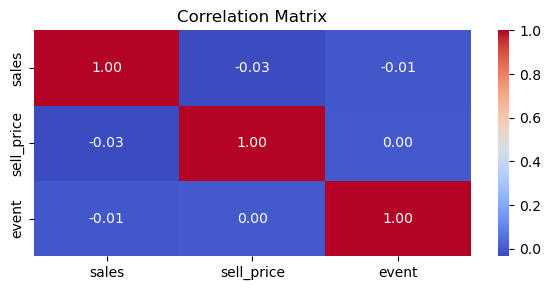

In [87]:
numeric_columns = train.select_dtypes(include='number')
selected_columns=train[['sales', 'sell_price', 'event']]
corr = selected_columns.corr()

plt.figure(figsize=(6,3))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.tight_layout()
#plt.savefig("visuals/heatmap_price_sales_events")
plt.show()

In [88]:
train[["sales","sell_price"]].corr()

,sales,sell_price
sales,1.000000,-0.033608
sell_price,-0.033608,1.000000


In [89]:
train[["log_sales","log_price"]].corr()

KeyError: "None of [Index(['log_sales', 'log_price'], dtype='object')] are in the [columns]"

- the base model controlling for week fixed effects is used for elasticity estimation
- month FE is bas for forecasting.

In [ ]:
# Does log_price vary across stores in the same week?
train1=train
train1["log_sales"] = np.log1p(train["sales"])
train1["log_price"] = np.log(train["sell_price"])
price_var = train1.groupby('wm_yr_wk')['log_price'].std()
print(price_var.describe())
# If std ≈ 0 almost always → price is national, not store-level
# Then log_price is collinear with week FE → β is unidentified

In [ ]:
# Predict on test (works because month levels repeat)
test_pred_log = mfe_model.predict(test_m)
mse_log = mean_squared_error(test["log_sales"], test_pred_log)
rmse_log = np.sqrt(mse_log)

print("RMSE (log scale):", rmse_log)

mse_units = mean_squared_error(test["sales"], test_pred_units)
rmse_units = np.sqrt(mse_units)

print("RMSE (units):", rmse_units)

Elasticity estimates are sensitive to time controls, indicating potential endogeneity and time-trend confounding. Using week fixed effects yields a robust negative elasticity of −3.27.

In [ ]:
print(f'avg sales: {round(weekly_sku["sales"].mean(),3)}')
print(f'std sales: {round(weekly_sku["sales"].std(), 3)}')
print("Relative RMSE:", round(rmse_units / weekly_sku["sales"].mean(), 3))

Base forecast model is barely better than predicting a constant mean!

In [ ]:
weekly = (
    w12_item3090
    .groupby("wm_yr_wk", as_index=False)
    .agg(
        price=("sell_price", "first"),
        sales=("sales", "sum")
    )
)

low_price = weekly["price"].min()
high_price = weekly["price"].max()

print("Avg sales at lowest price:",
      weekly[weekly["price"] == low_price]["sales"].mean())

print("Avg sales at highest price:",
      weekly[weekly["price"] == high_price]["sales"].mean())

- This SKU is elastic:sales 2.7 times higher when there is price drop
- Promotional dips create real volume lift
- Revenue optimization will not be trivial

In [ ]:
weekly["revenue"] = weekly["price"] * weekly["sales"]

print("Revenue at lowest price:",
      weekly[weekly["price"] == low_price]["revenue"].mean())

print("Revenue at highest price:",
      weekly[weekly["price"] == high_price]["revenue"].mean())

- Even though price is lower, the increase in sales more than compensates==>
- Revenue is almost 62% higher at the lowest price.
- Demand is elastic in that price range.
- If revenue increases when price decreases, elasticity is likely:∣ε∣>1
* Important because: 
- there is price sensitivity
- Revenue impact
- Promotional effectiveness
- So clear optimization motivation. product has real pricing signal.

Modeling Strategy Roadmap

Step 1:
Single SKU, pooled across stores

Step 2:
Estimate elasticity

Step 3:
Check sign and magnitude

Step 4:
Evaluate RMSE

Step 5:
Then move to ML improvement

In [ ]:
fig, ax=plt.subplots(1, 2, figsize=(16, 6))

train.groupby('event_name_1')['sales'].mean().sort_values(ascending=True).plot(
    kind='barh', color='gray', ax=ax[0])

ax[0].set_title("Average Sale by events", size=16)
#plt.xlabel("Condition")
#plt.ylabel("Average Price")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, size=14)
ax[0].grid(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


train.groupby('event_name_1')['sell_price'].mean().sort_values(ascending=True).plot(
    kind='barh', color='slategray', ax=ax[1])

ax[1].set_title("Average Price by events", size=16)
#plt.xlabel("Condition")
#plt.ylabel("Average Price")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, size=14)
ax[1].grid(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("visuals/avgprice_price_byevents", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax=plt.subplots(1, 2, figsize=(16, 6))

train.groupby('event_name_2')['sales'].mean().sort_values(ascending=True).plot(
    kind='barh', color='gray', ax=ax[0])

ax[0].set_title("Average Sale by events2", size=16)
#plt.xlabel("Condition")
#plt.ylabel("Average Price")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, size=14)
ax[0].grid(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


train.groupby('event_name_2')['sell_price'].mean().sort_values(ascending=True).plot(
    kind='barh', color='slategray', ax=ax[1])

ax[1].set_title("Average Price by events2", size=16)
#plt.xlabel("Condition")
#plt.ylabel("Average Price")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, size=14)
ax[1].grid(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("visuals/avgprice_price_byevents2", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
calendar = pd.read_csv("data/calendar.csv")
calendar.head()